<a href="https://colab.research.google.com/github/Dener013/gamma_telescope_pipeline_ml/blob/main/esteira_de_aprendizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MAGIC Gamma Telescope Dataset

**Problema:** Classificação Binária — Raios Gama vs Hádrons  
**Fonte:** https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope

---
O experimento MAGIC (Major Atmospheric Gamma Imaging Cherenkov) detecta raios gama de alta energia
provenientes de fontes cósmicas, distinguindo-os do ruído de fundo de hádrons atmosféricos.
Objetivo: classificar eventos em **gamagênico (g)** ou **hadrônico (h)**.

Ajuste para o collab

In [21]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_gamma, n_hadron = 12332, 6688

gamma = pd.DataFrame({
    'fLength': np.random.lognormal(2.0, 0.7, n_gamma),
    'fWidth':  np.random.lognormal(1.5, 0.6, n_gamma),
    'fSize':   np.random.normal(2.8, 0.4, n_gamma),
    'fConc':   np.random.beta(3, 5, n_gamma),
    'fConc1':  np.random.beta(2, 4, n_gamma),
    'fAsym':   np.random.normal(0, 50, n_gamma),
    'fM3Long': np.random.normal(0, 30, n_gamma),
    'fM3Trans':np.random.normal(0, 15, n_gamma),
    'fAlpha':  np.abs(np.random.normal(0, 15, n_gamma)),
    'fDist':   np.random.normal(200, 60, n_gamma),
    'class': 'g'
})
hadron = pd.DataFrame({
    'fLength': np.random.lognormal(2.3, 0.8, n_hadron),
    'fWidth':  np.random.lognormal(1.8, 0.7, n_hadron),
    'fSize':   np.random.normal(2.7, 0.5, n_hadron),
    'fConc':   np.random.beta(2, 6, n_hadron),
    'fConc1':  np.random.beta(1.5, 5, n_hadron),
    'fAsym':   np.random.normal(0, 70, n_hadron),
    'fM3Long': np.random.normal(0, 40, n_hadron),
    'fM3Trans':np.random.normal(0, 20, n_hadron),
    'fAlpha':  np.abs(np.random.normal(30, 25, n_hadron)),
    'fDist':   np.random.normal(220, 70, n_hadron),
    'class': 'h'
})

df_raw = pd.concat([gamma, hadron]).sample(frac=1, random_state=42).reset_index(drop=True)
df_raw.to_csv("magic04.data", index=False)
print("magic04.data gerado!")

magic04.data gerado!


## 1. Importação de Bibliotecas

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    ConfusionMatrixDisplay, roc_curve, auc
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

import sklearn
print(f"  numpy {np.__version__}  |  pandas {pd.__version__}  |  sklearn {sklearn.__version__}")

  numpy 2.0.2  |  pandas 2.2.2  |  sklearn 1.6.1


## 2. Carregamento do Dataset


| Atributo | Descrição |
|---|---|
| fLength | Comprimento do eixo maior da elipse (mm) |
| fWidth | Comprimento do eixo menor da elipse (mm) |
| fSize | Soma dos conteúdos dos pixels em log10 (ph.e.) |
| fConc | Razão entre os 2 pixels mais brilhantes e fSize |
| fConc1 | Razão entre o pixel mais brilhante e fSize |
| fAsym | Distância do pixel mais brilhante ao centro (mm) |
| fM3Long | 3º momento ao longo do eixo maior (mm) |
| fM3Trans | 3º momento ao longo do eixo menor (mm) |
| fAlpha | Ângulo do eixo maior com o vetor de posição (graus) |
| fDist | Distância do centro de gravidade à origem (mm) |
| class | **g** = sinal gama · **h** = fundo hadrônico |

In [23]:
try:
    from ucimlrepo import fetch_ucirepo
    magic = fetch_ucirepo(id=159)
    df = pd.concat([magic.data.features, magic.data.targets], axis=1)
    df.columns = ['fLength','fWidth','fSize','fConc','fConc1',
                  'fAsym','fM3Long','fM3Trans','fAlpha','fDist','class']
    print("Dataset carregado via ucimlrepo")
except Exception:
    df = pd.read_csv("magic04.data")
    print("Dataset carregado via CSV local")

print(f"\nDimensoes: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Classes  : {dict(df['class'].value_counts())}")
df.head(10)

Dataset carregado via CSV local

Dimensoes: 19,020 linhas x 11 colunas
Classes  : {'g': np.int64(12332), 'h': np.int64(6688)}


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.065914,5.689256,2.581599,0.257736,0.302996,-4.566652,12.325018,26.916382,11.165021,223.107985,h
1,9.769785,7.929850,2.675896,0.582337,0.464907,2.730652,-7.624582,-16.563766,7.283896,128.092232,g
2,5.086141,8.852704,3.374076,0.238725,0.352615,-74.518841,-1.830139,-8.846988,6.857758,131.822510,g
3,11.160836,3.451937,2.109339,0.064767,0.399739,133.084593,30.350809,7.151381,45.456198,297.730233,h
4,19.806066,9.401388,2.846702,0.241249,0.063718,-48.543516,-5.758349,34.018567,78.437623,170.812550,h
5,9.342189,2.965812,1.801281,0.511885,0.314607,-16.486615,-28.928795,1.880307,5.817056,203.474882,g
6,8.022997,2.241687,2.845451,0.288180,0.305869,104.350022,-0.498418,-2.332913,17.478109,115.870171,g
7,7.329402,10.463754,3.211337,0.253319,0.283605,-99.481572,33.286835,12.589177,49.490600,193.543739,h
8,43.914220,2.348537,2.684802,0.321330,0.168706,15.883967,28.762509,21.731034,2.904269,157.115997,g
9,20.992636,4.819188,2.796373,0.263078,0.563197,-22.031855,6.665834,-15.624872,17.983775,199.198318,g


## 3. Estatísticas Descritivas Gerais



In [24]:
print("=" * 60)
print("INFORMACOES GERAIS DO DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("VALORES NULOS POR COLUNA")
print("=" * 60)
nulos = df.isnull().sum()
print(nulos.to_string())
print(f"\nTotal de nulos: {df.isnull().sum().sum()}")

INFORMACOES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB

VALORES NULOS POR COLUNA
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0

Total de nulos: 0


In [25]:
print("=" * 60)
print("ESTATISTICAS DESCRITIVAS — VARIAVEIS NUMERICAS")
print("=" * 60)
desc = df.describe().T
desc['cv%'] = (desc['std'] / desc['mean'].abs() * 100).round(1)
display(desc.round(4))

ESTATISTICAS DESCRITIVAS — VARIAVEIS NUMERICAS


,count,mean,std,min,25%,50%,75%,max,cv%
fLength,19020.0,10.9862,10.3098,0.4744,4.9213,8.1154,13.5273,299.6651,93.8
fWidth,19020.0,6.1894,4.7849,0.4432,3.1892,4.8977,7.6221,87.7316,77.3
fSize,19020.0,2.7619,0.4436,0.6347,2.4666,2.7678,3.0663,4.5246,16.1
fConc,19020.0,0.3324,0.1658,0.0029,0.2050,0.3178,0.4455,0.9144,49.9
fConc1,19020.0,0.2975,0.1761,0.0007,0.1582,0.2744,0.4143,0.9309,59.2
fAsym,19020.0,0.3377,57.9917,-271.8849,-37.9847,0.3094,38.3636,249.9492,17171.4
fM3Long,19020.0,-0.0888,33.6798,-134.1796,-22.2374,-0.0955,22.1859,147.0769,37925.2
fM3Trans,19020.0,0.0308,16.7545,-76.2841,-10.9747,-0.1690,10.8972,71.9599,54373.3
fAlpha,19020.0,19.4419,17.7695,0.0007,6.4883,14.1411,26.5517,120.9269,91.4
fDist,19020.0,206.7866,64.5855,-40.3232,163.4452,205.7303,249.1770,446.9861,31.2


In [26]:
print("=" * 60)
print("DISTRIBUICAO DA VARIAVEL ALVO")
print("=" * 60)
vc = df['class'].value_counts()
vc_pct = df['class'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Contagem': vc, 'Percentual (%)': vc_pct.round(2)})
summary.index.name = 'Classe'
display(summary)
print()
print("g = Raio Gama (sinal)  -> partícula de interesse (positivo)")
print("h = Hádron (ruído)     -> fundo atmosférico a descartar (negativo)")

DISTRIBUICAO DA VARIAVEL ALVO


,Contagem,Percentual (%)
Classe,,
g,12332,64.84
h,6688,35.16



g = Raio Gama (sinal)  -> partícula de interesse (positivo)
h = Hádron (ruído)     -> fundo atmosférico a descartar (negativo)


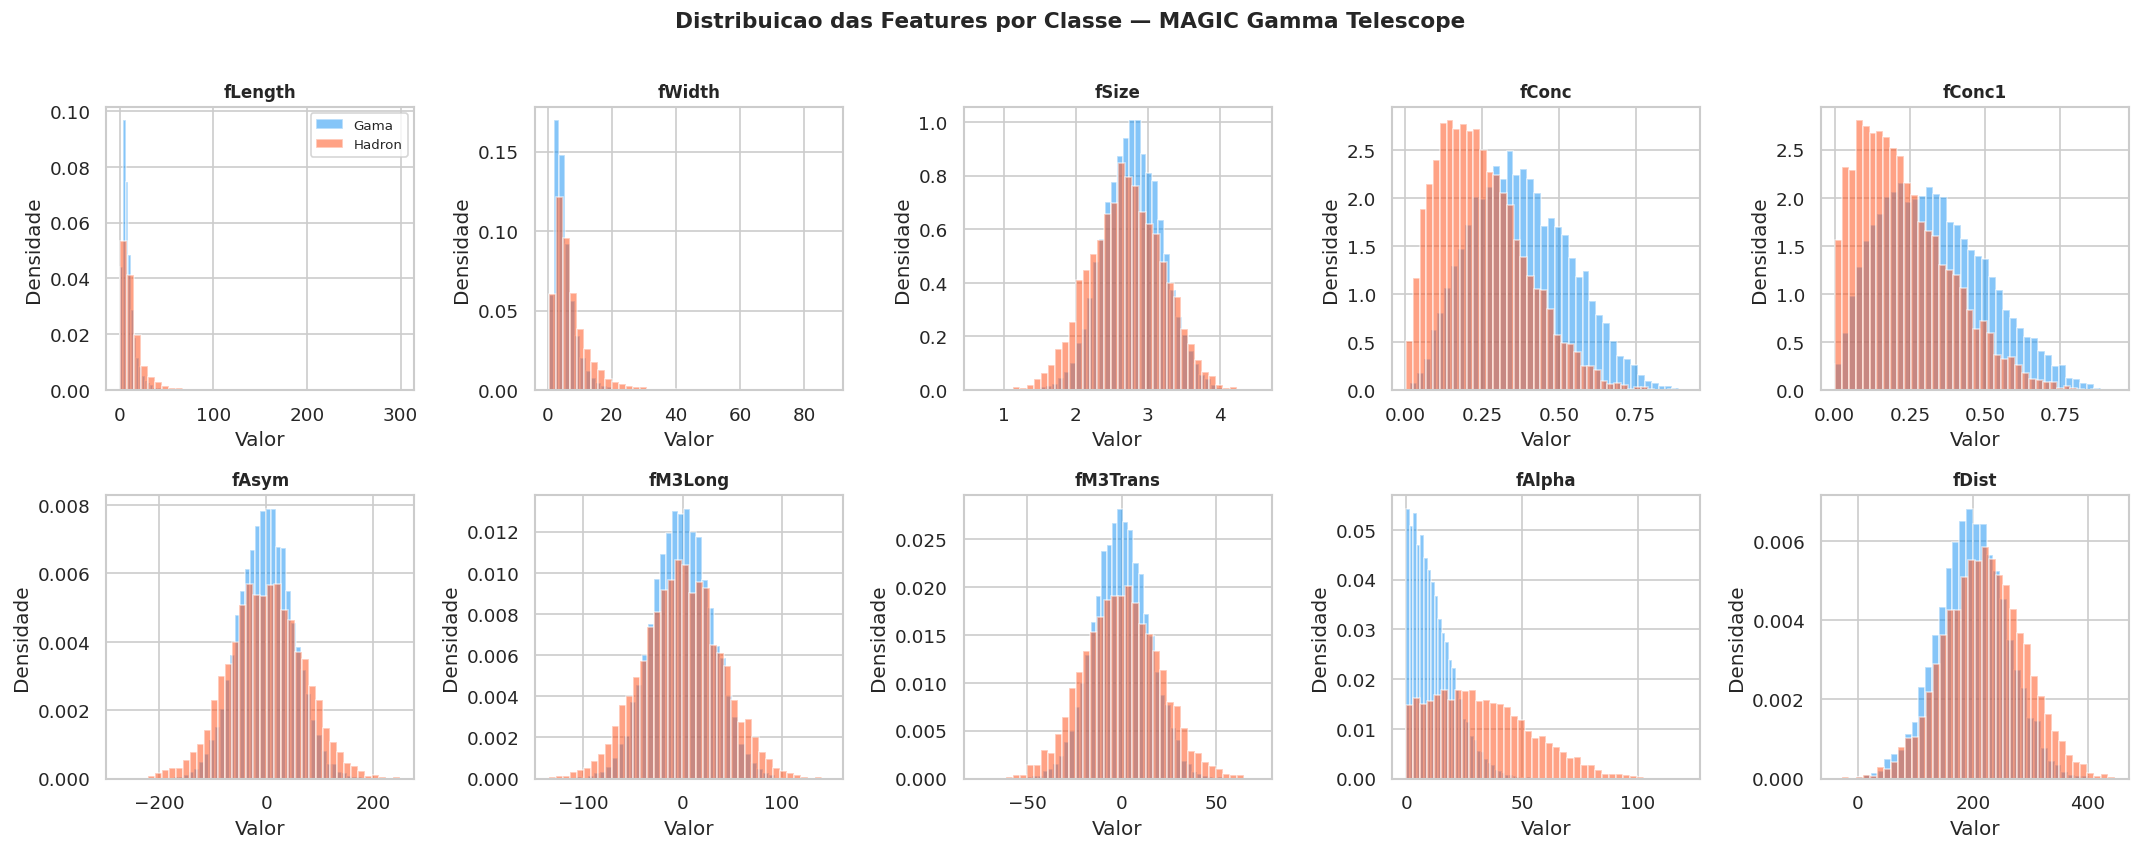

In [27]:
features = ['fLength','fWidth','fSize','fConc','fConc1',
            'fAsym','fM3Long','fM3Trans','fAlpha','fDist']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
palette = {'g': '#2196F3', 'h': '#FF5722'}

for i, col in enumerate(features):
    for cls, color in palette.items():
        subset = df[df['class'] == cls][col]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color,
                     label=f"{'Gama' if cls=='g' else 'Hadron'}", density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Densidade")
    if i == 0:
        axes[i].legend(fontsize=8)

fig.suptitle("Distribuicao das Features por Classe — MAGIC Gamma Telescope",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("distribuicoes.png", bbox_inches='tight')
plt.show()

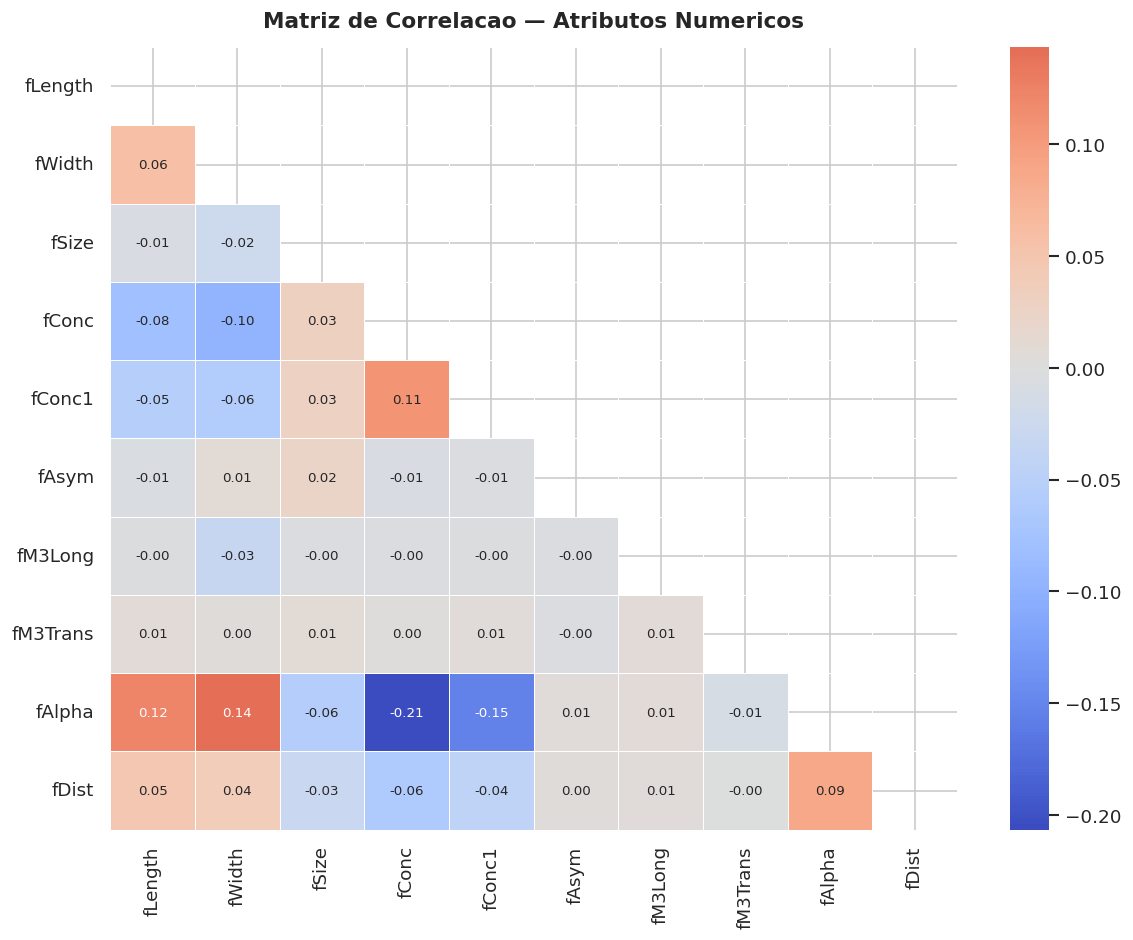

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Matriz de Correlacao — Atributos Numericos",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("correlacao.png", bbox_inches='tight')
plt.show()

## 4. Transformações nas Colunas

Transformações aplicadas:
- **Log-transform** em `fLength` e `fDist` — reduz a assimetria positiva (skewness).


In [29]:
df_proc = df.copy()

print("Skewness ANTES:")
print(df_proc[['fLength', 'fDist']].skew().to_string())

df_proc['fLength_log'] = np.log1p(df_proc['fLength'])
df_proc['fDist_log']   = np.log1p(df_proc['fDist'])

print("\nSkewness APOS log-transform (novas colunas):")
print(df_proc[['fLength_log', 'fDist_log']].skew().to_string())

print("\nTransformacoes de colunas concluidas!")


Skewness ANTES:
fLength    4.670890
fDist      0.047553

Skewness APOS log-transform (novas colunas):
fLength_log    0.343711
fDist_log     -1.799591

Transformacoes de colunas concluidas!


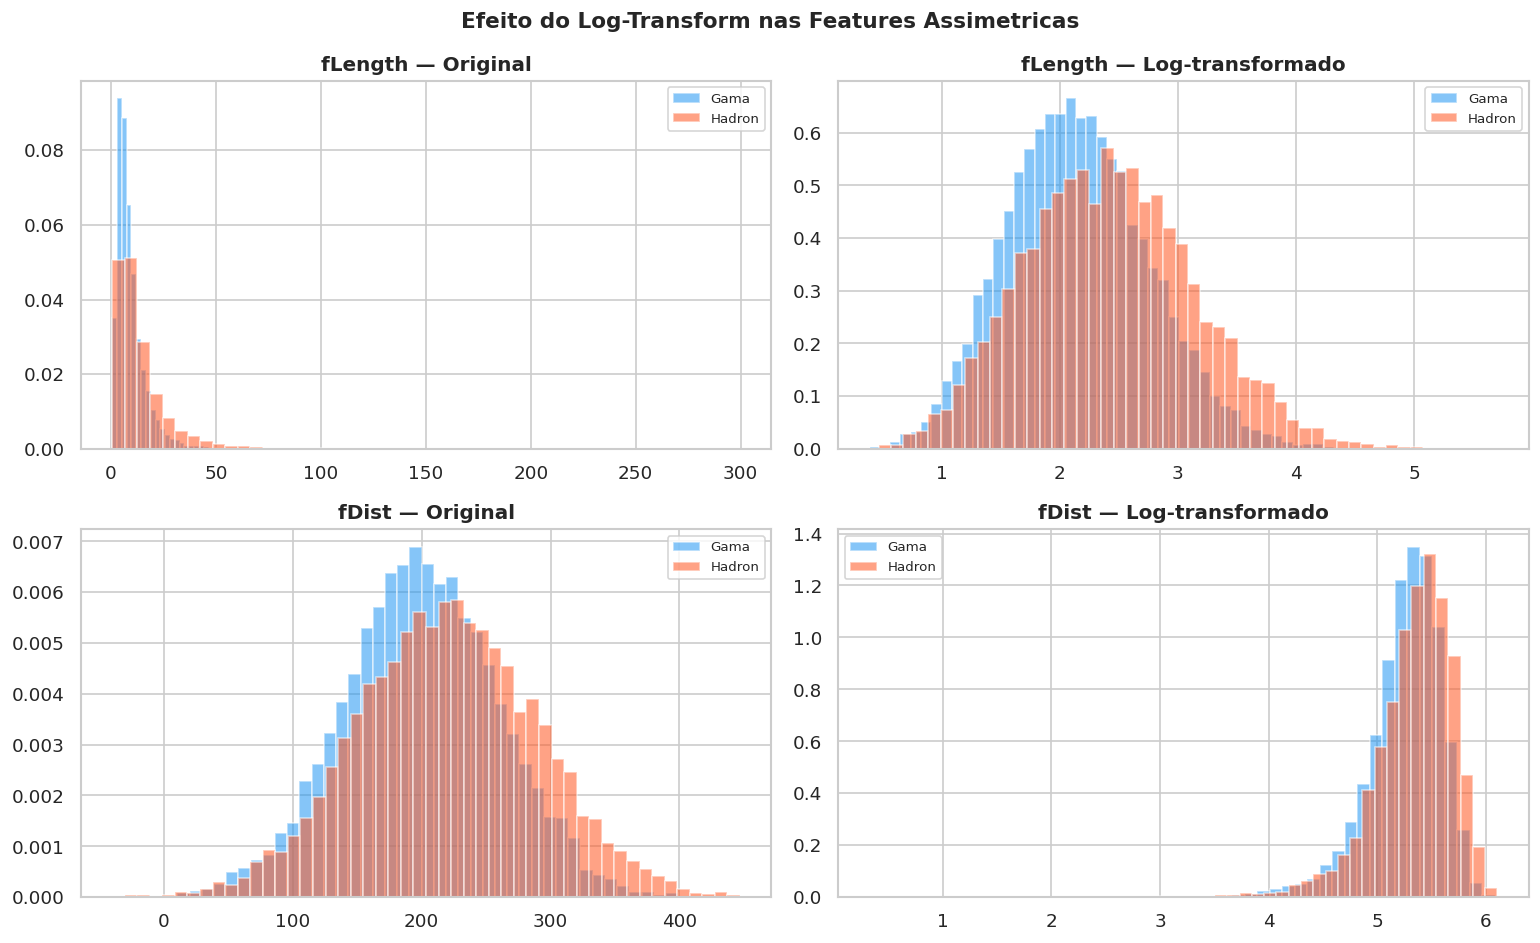

Transformacoes de colunas concluidas!


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
pares = [('fLength', 'fLength_log', 'fLength — Original', 'fLength — Log-transformado'),
         ('fDist',   'fDist_log',   'fDist — Original',   'fDist — Log-transformado')]

for row, (col_orig, col_log, titulo_orig, titulo_log) in enumerate(pares):
    for col, titulo, ax in [(col_orig, titulo_orig, axes[row][0]),
                             (col_log,  titulo_log,  axes[row][1])]:
        for cls, color in {'g': '#2196F3', 'h': '#FF5722'}.items():
            subset = df_proc[df_proc['class'] == cls][col]
            ax.hist(subset, bins=50, alpha=0.55, color=color,
                    label=f"{'Gama' if cls=='g' else 'Hadron'}", density=True)
        ax.set_title(titulo, fontweight='bold')
        ax.legend(fontsize=8)

fig.suptitle("Efeito do Log-Transform nas Features Assimetricas",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("transformacao_colunas.png", bbox_inches='tight')
plt.show()
print("Transformacoes de colunas concluidas!")

## 5. Transformações nas Linhas

In [31]:
features_model = ['fLength','fWidth','fSize','fConc','fConc1',
                  'fAsym','fM3Long','fM3Trans','fAlpha','fDist']

n_antes = len(df_proc)
mask_valid = pd.Series([True] * n_antes, index=df_proc.index)

for col in features_model:
    Q1 = df_proc[col].quantile(0.25)
    Q3 = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR
    mask_valid &= (df_proc[col] >= lower) & (df_proc[col] <= upper)

df_clean = df_proc[mask_valid].reset_index(drop=True)
n_depois = len(df_clean)
n_removidos = n_antes - n_depois

print(f"Linhas antes  da limpeza   : {n_antes:>7,}")
print(f"Linhas removidas (outliers): {n_removidos:>5,}  ({n_removidos/n_antes*100:.2f}%)")
print(f"Linhas apos   a limpeza    : {n_depois:>7,}")
print("\nDistribuicao apos limpeza:")
print(df_clean['class'].value_counts().to_string())

Linhas antes  da limpeza   :  19,020
Linhas removidas (outliers):   792  (4.16%)
Linhas apos   a limpeza    :  18,228

Distribuicao apos limpeza:
class
g    12168
h     6060


## 6. Divisão em Subconjuntos: Treino / Validação / Teste

| Subconjunto | Proporção |
|---|---|
| **Treino** | 60 % |
| **Validação** | 20 % |
| **Teste** | 20 % |


In [32]:
from sklearn.preprocessing import LabelEncoder

X = df_clean[features_model].values

# Encoding direto aqui, sem precisar de coluna separada
le = LabelEncoder()
y = le.fit_transform(df_clean['class'].values)  # g->1, h->0

print(f"Total de amostras: {len(X):,}")
print(f"Classes — 1=gama: {(y==1).sum():,}  |  0=hadron: {(y==0).sum():,}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(f"\n{'Subconjunto':<15} {'Amostras':>10} {'Gama (%)':>10} {'Hadron (%)':>12}")
print("-" * 50)
for nome, X_s, y_s in [("Treino", X_train, y_train),
                        ("Validacao", X_val, y_val),
                        ("Teste", X_test, y_test)]:
    n = len(y_s)
    pg = (y_s==1).sum() / n * 100
    ph = (y_s==0).sum() / n * 100
    print(f"{nome:<15} {n:>10,} {pg:>9.1f}% {ph:>10.1f}%")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("\nNormalizacao (StandardScaler) aplicada — sem data leakage!")

Total de amostras: 18,228
Classes — 1=gama: 6,060  |  0=hadron: 12,168

Subconjunto       Amostras   Gama (%)   Hadron (%)
--------------------------------------------------
Treino              10,936      33.2%       66.8%
Validacao            3,646      33.2%       66.8%
Teste                3,646      33.2%       66.8%

Normalizacao (StandardScaler) aplicada — sem data leakage!


## 7. Treinamento e Avaliação do Modelo


**Modelo:** Random Forest Classifier  

In [33]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Modelo treinado!")
print(f"  Estimadores: {rf.n_estimators}  |  Profundidade maxima: {rf.max_depth}")


y_val_pred = rf.predict(X_val)
acc_val = accuracy_score(y_val, y_val_pred)
print(f"\nAcuracia na Validacao: {acc_val:.4f} ({acc_val*100:.2f}%)")
print()
print("Relatorio de Classificacao — Validacao:")
print(classification_report(y_val, y_val_pred, target_names=['Hadron (0)','Gama (1)']))

Modelo treinado!
  Estimadores: 200  |  Profundidade maxima: 20

Acuracia na Validacao: 0.8502 (85.02%)

Relatorio de Classificacao — Validacao:
              precision    recall  f1-score   support

  Hadron (0)       0.86      0.92      0.89      2434
    Gama (1)       0.82      0.70      0.76      1212

    accuracy                           0.85      3646
   macro avg       0.84      0.81      0.82      3646
weighted avg       0.85      0.85      0.85      3646



## 8. Matriz de Confusão e Acurácia

RESULTADOS FINAIS — CONJUNTO DE TESTE

Acuracia: 0.8626  (86.26%)

Relatorio de Classificacao:
              precision    recall  f1-score   support

      Hadron       0.87      0.93      0.90      2434
        Gama       0.83      0.73      0.78      1212

    accuracy                           0.86      3646
   macro avg       0.85      0.83      0.84      3646
weighted avg       0.86      0.86      0.86      3646



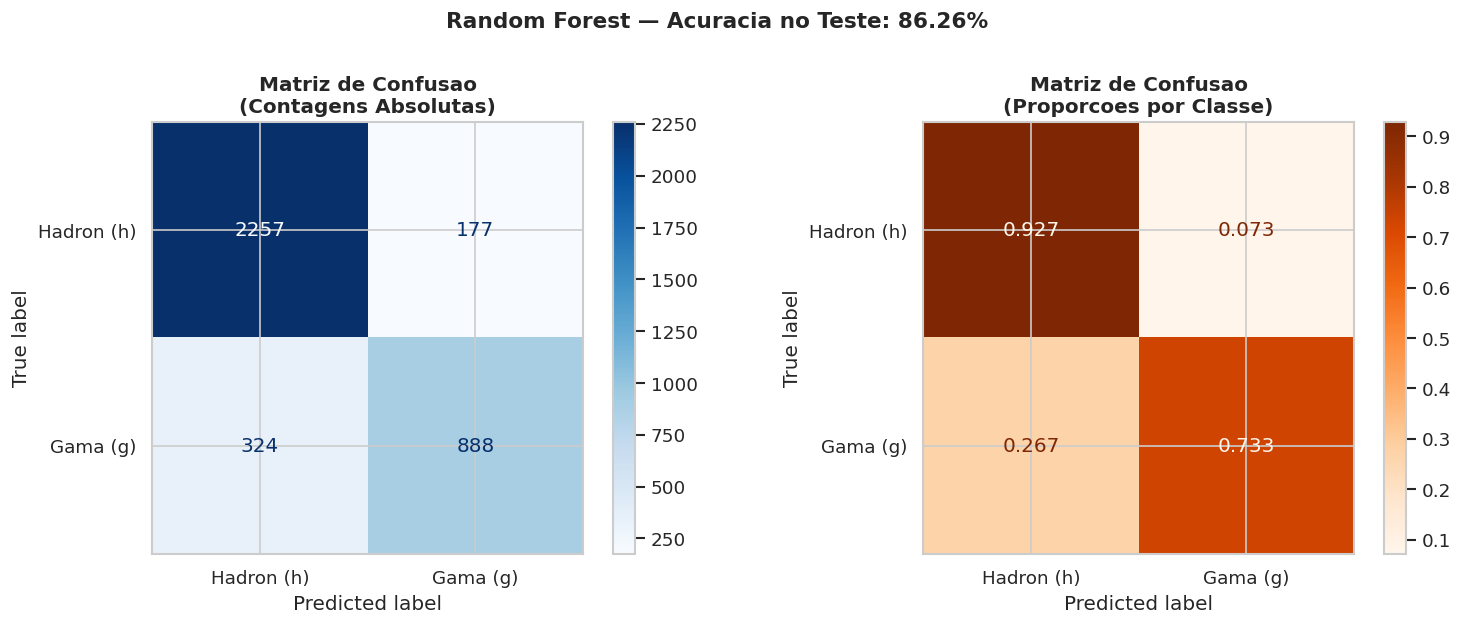

In [34]:
y_test_pred = rf.predict(X_test)
y_test_prob = rf.predict_proba(X_test)[:, 1]
acc_test = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("=" * 60)
print("RESULTADOS FINAIS — CONJUNTO DE TESTE")
print("=" * 60)
print(f"\nAcuracia: {acc_test:.4f}  ({acc_test*100:.2f}%)")
print()
print("Relatorio de Classificacao:")
print(classification_report(y_test, y_test_pred, target_names=['Hadron','Gama']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


ConfusionMatrixDisplay(cm, display_labels=['Hadron (h)','Gama (g)']).plot(
    ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title("Matriz de Confusao\n(Contagens Absolutas)",
                   fontsize=12, fontweight='bold')


cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Hadron (h)','Gama (g)']).plot(
    ax=axes[1], colorbar=True, cmap='Oranges', values_format='.3f')
axes[1].set_title("Matriz de Confusao\n(Proporcoes por Classe)",
                   fontsize=12, fontweight='bold')

fig.suptitle(f"Random Forest — Acuracia no Teste: {acc_test*100:.2f}%",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("matriz_confusao.png", bbox_inches='tight')
plt.show()

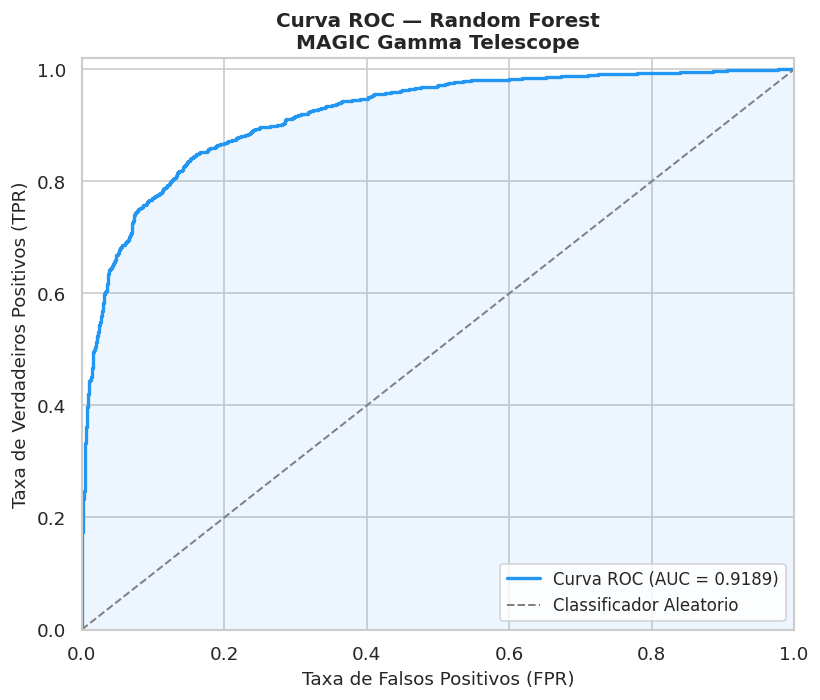

AUC-ROC = 0.9189


In [35]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2196F3', lw=2,
        label=f'Curva ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.2,
        label='Classificador Aleatorio')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2196F3')
ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=11)
ax.set_title("Curva ROC — Random Forest\nMAGIC Gamma Telescope",
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("roc_curve.png", bbox_inches='tight')
plt.show()
print(f"AUC-ROC = {roc_auc:.4f}")

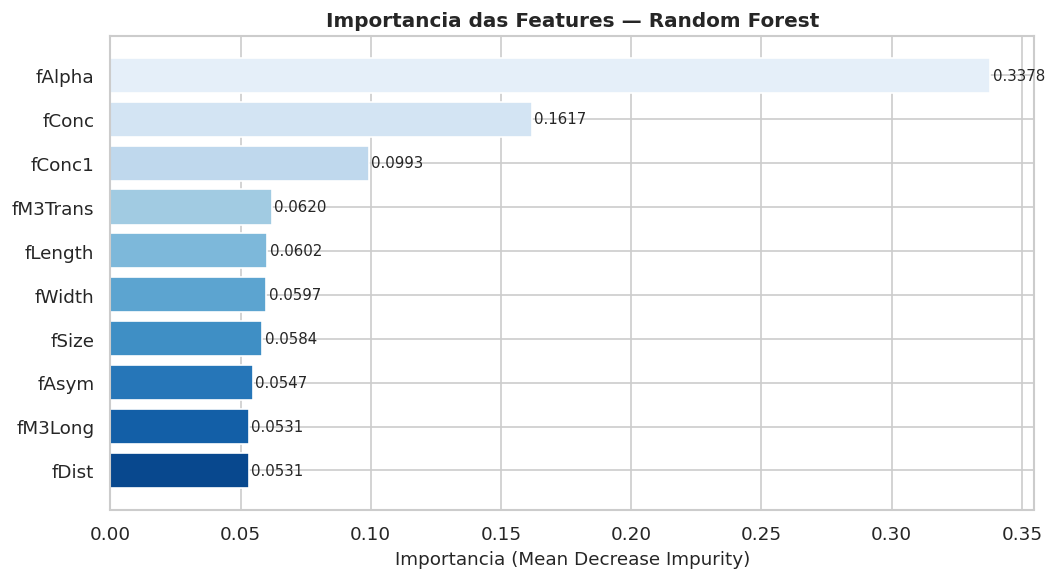

In [36]:
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
feat_sorted = [features_model[i] for i in idx]
imp_sorted  = importances[idx]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_sorted[::-1], imp_sorted[::-1],
               color=sns.color_palette("Blues_r", len(features_model)))
ax.set_xlabel("Importancia (Mean Decrease Impurity)", fontsize=11)
ax.set_title("Importancia das Features — Random Forest",
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, imp_sorted[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("importancia_features.png", bbox_inches='tight')
plt.show()

## 9. Predição do Modelo Implantado

In [37]:
novos_eventos = pd.DataFrame([
    {'fLength': 28.7, 'fWidth': 16.0, 'fSize': 2.6, 'fConc': 0.39, 'fConc1': 0.22,
     'fAsym':  3.0, 'fM3Long': 22.0, 'fM3Trans':  8.0, 'fAlpha':  5.0, 'fDist': 176.0,
     'descricao': 'Provavel GAMA'},
    {'fLength': 52.3, 'fWidth': 26.1, 'fSize': 2.5, 'fConc': 0.22, 'fConc1': 0.13,
     'fAsym': 40.0, 'fM3Long': 55.0, 'fM3Trans': 18.0, 'fAlpha': 48.0, 'fDist': 295.0,
     'descricao': 'Provavel HADRON'},
    {'fLength': 35.0, 'fWidth': 19.5, 'fSize': 2.8, 'fConc': 0.32, 'fConc1': 0.18,
     'fAsym': 10.0, 'fM3Long': 30.0, 'fM3Trans': 10.0, 'fAlpha': 18.0, 'fDist': 210.0,
     'descricao': 'Ambiguo'},
])

X_novo = scaler.transform(novos_eventos[features_model].values)
predicoes = rf.predict(X_novo)
probabilidades = rf.predict_proba(X_novo)

label_map = {0: 'HADRON (h)', 1: 'GAMA (g)'}

print("=" * 72)
print(f"{'RESULTADOS DAS PREDICOES':^72}")
print("=" * 72)
print(f"{'Evento':<12} {'Descricao':<20} {'Predicao':<14} {'P(Gama)':>10} {'P(Hadron)':>10}")
print("-" * 72)

for i, (pred, probs) in enumerate(zip(predicoes, probabilidades)):
    icon  = "⚡" if pred == 1 else "💥"
    descr = novos_eventos.iloc[i]['descricao']
    print(f"Evento {i+1:<5} {descr:<20} {icon} {label_map[pred]:<12} {probs[1]:>10.4f} {probs[0]:>10.4f}")

print("-" * 72)
print()
print("⚡ GAMA    = raio gama detectado (sinal de interesse)")
print("💥 HADRON  = hádron atmosférico (ruído de fundo)")

                        RESULTADOS DAS PREDICOES                        
Evento       Descricao            Predicao          P(Gama)  P(Hadron)
------------------------------------------------------------------------
Evento 1     Provavel GAMA        💥 HADRON (h)       0.3424     0.6576
Evento 2     Provavel HADRON      ⚡ GAMA (g)         0.9668     0.0332
Evento 3     Ambiguo              ⚡ GAMA (g)         0.5425     0.4575
------------------------------------------------------------------------

⚡ GAMA    = raio gama detectado (sinal de interesse)
💥 HADRON  = hádron atmosférico (ruído de fundo)


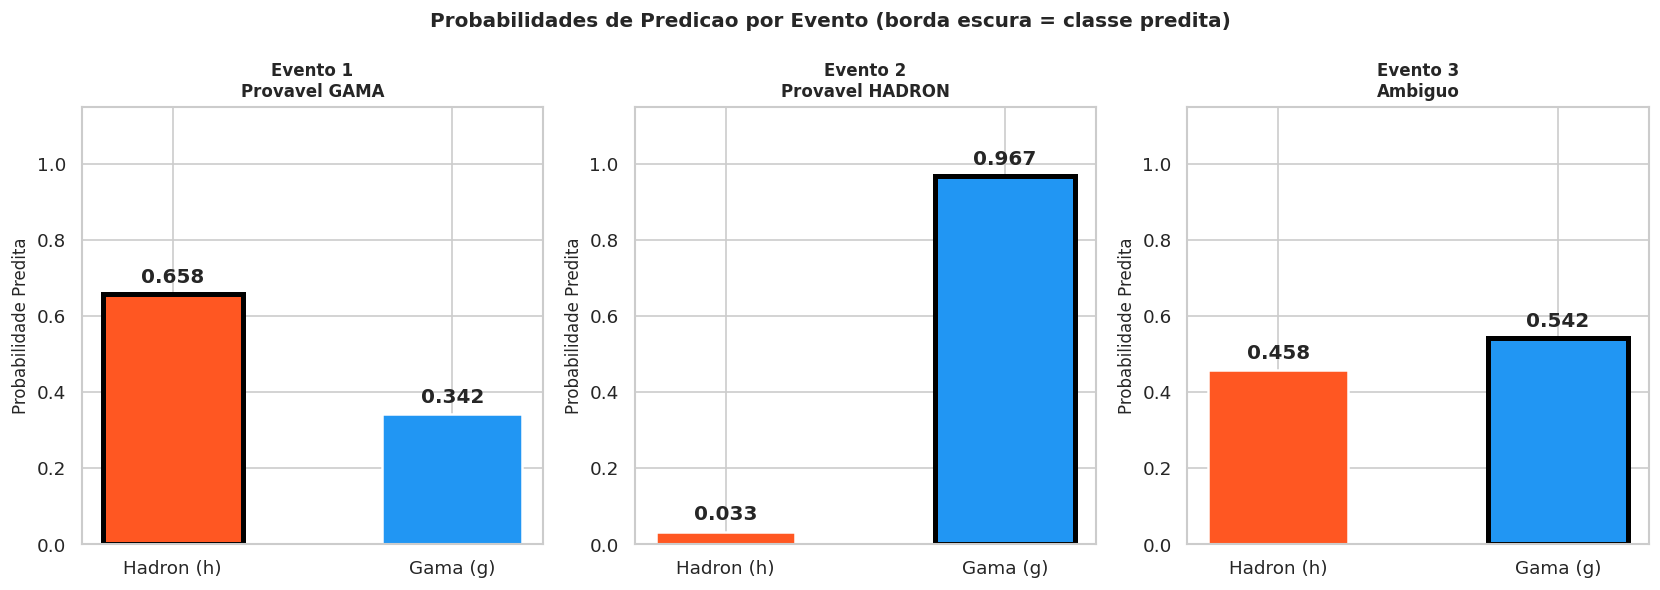

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cores   = ['#FF5722', '#2196F3']
rotulos = ['Hadron (h)', 'Gama (g)']

for i, ax in enumerate(axes):
    probs = probabilidades[i]
    bars  = ax.bar(rotulos, probs, color=cores, edgecolor='white',
                   linewidth=1.5, width=0.5)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Probabilidade Predita", fontsize=10)
    ax.set_title(f"Evento {i+1}\n{novos_eventos.iloc[i]['descricao']}",
                 fontsize=10, fontweight='bold')
    for bar, val in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    bars[predicoes[i]].set_edgecolor('black')
    bars[predicoes[i]].set_linewidth(3)

fig.suptitle("Probabilidades de Predicao por Evento (borda escura = classe predita)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("predicoes.png", bbox_inches='tight')
plt.show()